# Decompositions of the circulation

## Introduction

In the previous chapter, we looked at time averaged quantities.

It's often going to be useful to consider this total flow as consisting of a *mean* and a *fluctuating* part.

## Time mean and zonal mean

We consider two means that are often used: *time* mean and *zonal* mean, along with deviations from these means.

We define the time mean as

$$ \overline{A} = \frac{1}{T} \int_0^T A dt $$

and the zonal mean as

$$ \left[ A \right] = \frac{1}{2\pi} \int_0^{2\pi} A d\lambda $$

where $t$ is time, $T$ is the total time interval over which we are averaging, $\lambda$ is longitude, and $A$ is whatever variable we are averaging.

This introduces a standardized notation, where the overbar will always indicate time averages and the square brackets will be reserved for zonal averages.

### Example

**Prove that the zonal and time mean mass flux across any latitude circle must vanish, for time scales greater than a year.**

Let's start with the continuity (mass) equation in pressure coordinates:

$$ \nabla \cdot \vec{u} = 0 $$

which we can write out in spherical coordinates like so:

$$ \frac{1}{a \cos\phi}\frac{\partial u }{\partial \lambda} + \frac{1}{a \cos\phi} \frac{\partial \left( v \cos\phi \right)}{\partial \phi}  + \frac{\partial \omega}{\partial p} $$

So if we take the time and zonal average of the continuity equation we get

$$ \left[ \frac{1}{a \cos\phi}\frac{\partial \overline{u} }{\partial \lambda} \right] + \left[ \frac{1}{a \cos\phi} \frac{\partial \left( \overline{v} \cos\phi \right)}{\partial \phi} \right] + \left[ \frac{\partial \overline{\omega}}{\partial p} \right] $$

which we can also write as

$$ \frac{1}{2 \pi a \cos\phi}\int_0^{2\pi} \frac{\partial \overline{u} }{\partial \lambda} d\lambda + \frac{1}{a \cos\phi} \frac{\partial }{\partial \phi} \left( \left[ \overline{v} \right] \cos\phi \right)  + \frac{\partial \left[ \overline{\omega} \right]}{\partial p}  $$

The first term is zero. **Why?**

Let's now integrate over the depth of the atmosphere, from surface pressure $p_s$ to zero:

$$  \frac{1}{a \cos\phi} \frac{\partial }{\partial \phi} \left( \cos\phi \int_0^{p_s} \left[\overline{v}\right]  dp \right) + \int_0^{p_s} \frac{\partial \left[\overline{\omega}\right]}{\partial p} dp $$

The second term is the integral of a derivative so resolves to only boundary contributions. At the TOA $\omega(0) = 0$, and so the term simplifies to just

$$\left[\overline{\omega}\right] |_{p_s}$$

We cannot have flow in or out of the surface. The boundary condition is complicated by the fact that the surface pressure is not constant in time, but over timescales of a year or more we do not expect any time-averaged changes in surface pressure. Therefore

$$\left[\overline{\omega}\right] |_{p_s} \approx 0$$

and the average mass budget reduces to

$$ \frac{\partial}{\partial \phi} \left( \cos\phi \int_0^{p_s} \left[\overline{v}\right]\right) = 0 $$

so 

$$  \cos\phi \int_0^{p_s} \left[\overline{v}\right] = C $$

for some constant $C$

The integral above is proportional to the next mass flux across latitude circles. So what is the constant $C$?

One way to rationalize this is to consider the polar limit where $\phi \rightarrow \frac{\pi}{2}$ and thus $\cos\phi \rightarrow 0$. This would then require that the integral becomes unboundedly large if $C\ne 0$.

We conclude that $C=0$ for all $\phi$, and thus **the zonal and time mean mass flxu across any latitude circle must vanish**.

## Departures from the mean

Let's introduce some more standardized notation for departures from our two means

### Departure from time mean

$$ A^\prime \equiv A - \overline{A} $$

### Departure from zonal mean

$$ A^* \equiv A - \left[ A \right] $$

### Some identities

Note that 

$$ \overline{A^\prime} = 0 $$

and

$$ \left[ A^\prime \right] = 0 $$

as long as the averaging is the same as that used to find the perturbations.

Also the averages permute:

\begin{align*}
\left[ \overline{A} \right] &= \overline{ \left[ A \right] } & \overline{ \overline{A} } &= \overline{A} & \left[ \left[A \right] \right]
\end{align*}

### Combining zonal and time expansions

We can decompose the full field into four terms:

$$ A = \overline{A} + A^\prime = \left[\overline{A}\right] + \overline{A}^* + \left[ A^\prime \right] + A^{\prime *} $$

where our four terms are

1. Zonally symmetric part of the steady time-averaged quantities, e.g. trade winds and midlatitude westerlies $\left[ \overline{u} \right]$
2. Asymmetric part of the time-averaged quantities, e.g. monsoon circulations, PNA, NAO (patterns which vary on only low frequencies)
3. Instantaneous fluctutations of symmetric part of quantities, e.g. time fluctuations in Hadley cells, mean jet locations
4. Instantaneous, zonally asymmetric part of quantities, e.g. transient cyclones and anticyclones

## Examples using some real data

We are going to load in some zonal wind data $u$ from the ERA5 dataset.

For simplicity we'll just work with a few months of data here from a single year, and focus on a single pressure level (500 hPa, mid-troposphere).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
from arraylake import Client as alClient

In [ ]:
# ## If running this notebook on jupyterlab.its.albany.edu, uncomment and run this cell
# ##  This sets up a cluster of workers to parallelize the calculations

# from dask_jobqueue import SLURMCluster
# from dask.distributed import Client as dClient

# cluster = SLURMCluster(cores=64, # size of a single job -- typically one node of the HPC cluster
#                        memory="374GB",  # the max memory on the 64-core burst-daes nodes, I believe
#                        walltime="01:00:00",
#                        queue="burst-daes",
#                       )

# cluster.scale(1)
# dclient = dClient(cluster)
# dclient

In [2]:
alclient = alClient()
alclient.login()

Successfully refreshed tokens! Token stored at /Users/br546577/.arraylake/token.json

╭───────────────────────────────────────────────── User Details ──────────────────────────────────────────────────╮
│ Name: None None                                                                                                 │
│ Email: brose@albany.edu                                                                                         │
│ Id: 42b3a5b8-e618-4e14-aba8-632532f16692                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [3]:
repo = alclient.get_repo("earthmover-public/era5")
session = repo.readonly_session("main")
pressure_spatial = xr.open_zarr(session.store, group="pressure/spatial", chunks={})
pressure_spatial

<xarray.Dataset> Size: 327TB
Dimensions:         (valid_time: 756048, pressure_level: 13, latitude: 721,
                     longitude: 1440)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-03-31...
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    lsm             (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    sdor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    slor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    z_sfc           (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
Data variables:
    r               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    q               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    u               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    t               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    v               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    pv              (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    z               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    w               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
Attributes: (12/46)
    Conventions:                CF-1.7
    title:                      ERA5 Hourly Global Reanalysis - chunked for s...
    summary:                    ERA5 is the fifth generation ECMWF atmospheri...
    keywords:                   ERA5, reanalysis, atmosphere, climate, ECMWF,...
    keywords_vocabulary:        GCMD Science Keywords
    id:                         era5
    ...                         ...
    proj:code:                  EPSG:4326
    proj:epsg:                  4326
    GRIB_centre:                ecmf
    GRIB_centreDescription:     European Centre for Medium-Range Weather Fore...
    GRIB_subCentre:             0
    history:                    2026-05-05T13:36 GRIB to CDM+CF via cfgrib-0....

In [4]:
u500 = pressure_spatial.u.sel(pressure_level = 500., valid_time='2021')
u500

<xarray.DataArray 'u' (valid_time: 8760, latitude: 721, longitude: 1440)> Size: 36GB
dask.array<getitem, shape=(8760, 721, 1440), dtype=float32, chunksize=(1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 70kB 2021-01-01 ... 2021-12-3...
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    lsm             (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    sdor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    slor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    z_sfc           (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    pressure_level  float64 8B 500.0
Attributes: (12/31)
    GRIB_paramId:                             131
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           u
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                U component of wind
    units:                                    m s**-1
    standard_name:                            eastward_wind

In [5]:
# instantaneous u on one day
data = u500.sel(valid_time='2021-01-01T00').compute()
data

<xarray.DataArray 'u' (latitude: 721, longitude: 1440)> Size: 4MB
array([[ 3.05175781e-05,  3.05175781e-05,  3.05175781e-05, ...,
         3.05175781e-05,  3.05175781e-05,  3.05175781e-05],
       [-1.36601257e+01, -1.36054382e+01, -1.35487976e+01, ...,
        -1.38280945e+01, -1.37734070e+01, -1.37167664e+01],
       [-1.11523132e+01, -1.10917664e+01, -1.10331726e+01, ...,
        -1.13300476e+01, -1.12714539e+01, -1.12109070e+01],
       ...,
       [-1.85543823e+00, -1.85739136e+00, -1.86129761e+00, ...,
        -1.84567261e+00, -1.84957886e+00, -1.85153198e+00],
       [-1.78903198e+00, -1.78903198e+00, -1.78903198e+00, ...,
        -1.79098511e+00, -1.78903198e+00, -1.78903198e+00],
       [ 3.05175781e-05,  3.05175781e-05,  3.05175781e-05, ...,
         3.05175781e-05,  3.05175781e-05,  3.05175781e-05]],
      shape=(721, 1440), dtype=float32)
Coordinates:
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    lsm             (latitude, longitude) float32 4MB 0.0 0.0 0.0 ... 1.0 1.0
    sdor            (latitude, longitude) float32 4MB 0.0 0.0 ... 23.74 23.74
    slor            (latitude, longitude) float32 4MB 0.0001 0.0001 ... 0.002025
    z_sfc           (latitude, longitude) float32 4MB -1.24 -1.24 ... 2.772e+04
    pressure_level  float64 8B 500.0
    valid_time      datetime64[ns] 8B 2021-01-01
Attributes: (12/31)
    GRIB_paramId:                             131
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           u
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                U component of wind
    units:                                    m s**-1
    standard_name:                            eastward_wind

Let's make a helper function to draw maps of lat-lon data:

In [6]:
def make_map(field, levels=np.linspace(-75,75,31), title=None):
    p = field.plot.contourf(levels=levels,
                            subplot_kws={'projection': ccrs.EqualEarth()},
                                    transform=ccrs.PlateCarree())
    p.axes.coastlines()
    if title is not None:
        plt.title(title)
    return p

And make a map of the instantaneous $u$ on a particular day and time:

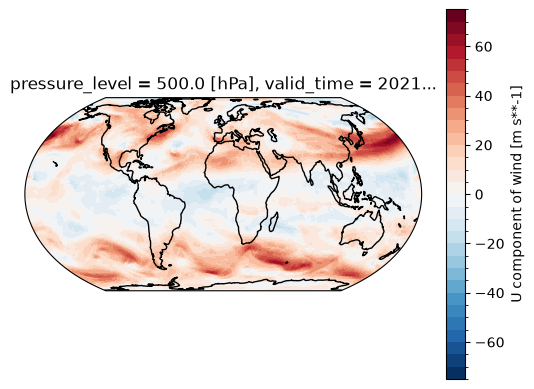

In [7]:
make_map(data);

To do some seasonal averaging, we need to pick a time interval. Let's choose all dates in January, February and March.

This is easy to do by slicing on the time axis:

In [8]:
# A time slice containing all of January, February and March
u500_JFM = u500.sel(valid_time=slice('2021-01-01','2021-03-31'))
u500_JFM

<xarray.DataArray 'u' (valid_time: 2160, latitude: 721, longitude: 1440)> Size: 9GB
dask.array<getitem, shape=(2160, 721, 1440), dtype=float32, chunksize=(1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 17kB 2021-01-01 ... 2021-03-3...
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    lsm             (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    sdor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    slor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    z_sfc           (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    pressure_level  float64 8B 500.0
Attributes: (12/31)
    GRIB_paramId:                             131
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           u
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                U component of wind
    units:                                    m s**-1
    standard_name:                            eastward_wind

This array has 2160 points on the time axis, corresponding to 31+28+31 = 90 days @ 24 times daily.

Let's make a map of $\overline{u}$ by taking a time average:

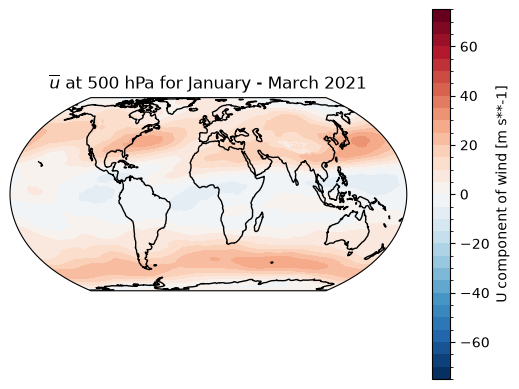

In [9]:
ubar = u500_JFM.mean(dim='valid_time').compute()
m = make_map(ubar, title=r'$\overline{u}$ at 500 hPa for January - March 2021')

If we further take the zonal average, we get $[\overline{u}]$

Since this quantity is one dimensional (latitude only), we'll make a line plot instead of a map:

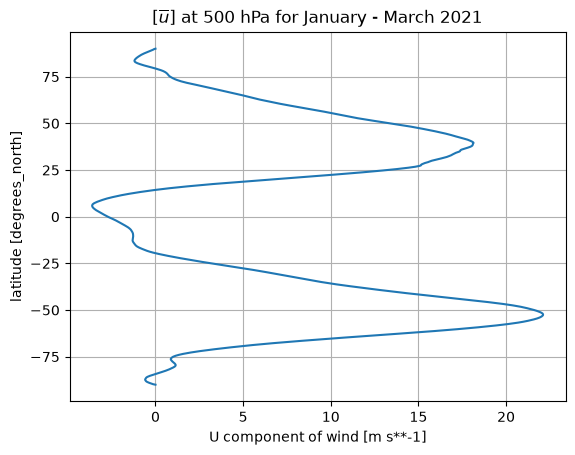

In [10]:
ubar.mean(dim=('longitude')).plot(y='latitude')
plt.title(r'$[\overline{u}]$ at 500 hPa for January - March 2021')
plt.grid();

Now here's $\overline{u^*}$, the time averaged departures from zonal mean:

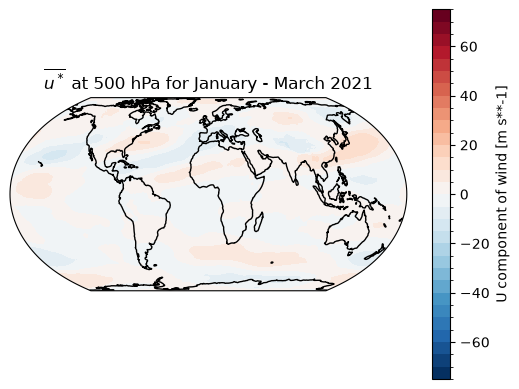

In [11]:
ustar = u500_JFM - u500_JFM.mean(dim='longitude')
ustarbar = ustar.mean(dim='valid_time').compute()
m = make_map(ustarbar, title=r'$\overline{u^*}$ at 500 hPa for January - March 2021')

And here's $u^\prime$ (departures from time average) at one instant:

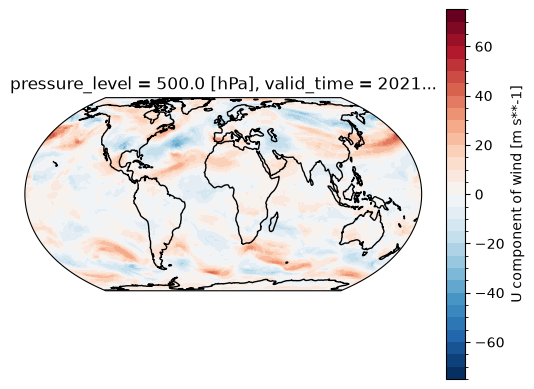

In [12]:
uprime = u500_JFM - ubar
make_map(uprime.sel(valid_time='2021-01-01T00'));

and its zonal average $[u^\prime]$ as a line plot:

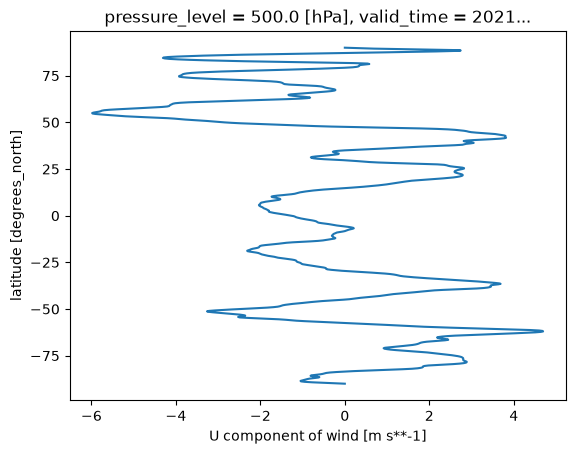

In [13]:
uprime.sel(valid_time='2021-01-01T00').mean(dim='longitude').plot(y='latitude')

And finally the deviations away from that zonal average $u^{\prime*}$

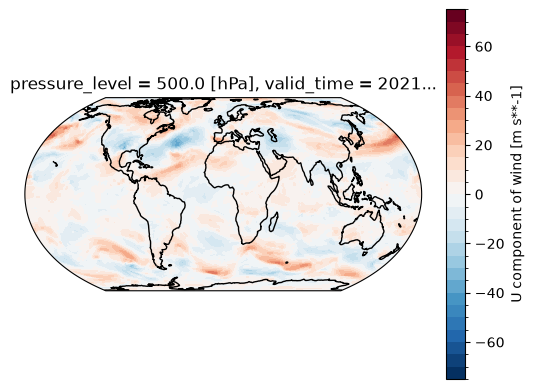

In [14]:
make_map((uprime - uprime.mean(dim='longitude')).sel(valid_time='2021-01-01T00'))

## Covariances between quantities

We are often interested in covariances between two quantities, usually a component of the flow and another scalar (e.g. meridional wind and temperature)

\begin{align*}
\overline{AB} &= \overline{\left( \overline{A} + A^\prime \right) \left(\overline{B} + B^\prime \right)} \\
&= \overline{\overline{A}~\overline{B}} + \overline{\overline{A} B^\prime} + \overline{A^\prime \overline{B}} + \overline{A^\prime B^\prime} \\
&= \overline{A}~\overline{B} + \overline{A} \overline{B^\prime} + \overline{B} \overline{A^\prime} + \overline{A^\prime B^\prime} \\
&= \overline{A}~\overline{B} +  \overline{A^\prime B^\prime}
\end{align*}

The last term is the *covariance* of $A$ and $B$ in time.

Similarly for the zonal average

$$\left[ AB \right] = \left[A\right] \left[B\right] + \left[ A^* B^* \right] $$
where the last term is the covariance of $A$ and $B$ is longitude.

We can also combine the time and zonal means

\begin{align*}
\left[\overline{AB}\right] &= \left[ \overline{A}~\overline{B} + \overline{A^\prime B^\prime} \right] \\
&= \left[\overline{A}\right]\left[\overline{B}\right] + \left[ \overline{A}^* \overline{B}^* \right] + \left[\overline{A^\prime B^\prime} \right]
\end{align*}

Three terms:
1. Mean meridional component
2. Stationary eddy component (zonal variations in time mean
3. Transient eddy component (time variations in time mean)

## Example: the meridional heat flux $vT$ at 500 hPa

Let $A = v$ and $B = T$

and let's consider the decomposition of the heat flux $vT$

Actually we are going to subtract the *global average* $\left< T \right>$ from the temperature data first so that the numbers are easier to interpret!

We will focus here on the single month of January 2021

In [15]:
jan2021 = slice('2021-01-01','2021-01-31')
v500 = pressure_spatial.v.sel(pressure_level = 500., valid_time=jan2021)
T500 = pressure_spatial.t.sel(pressure_level = 500., valid_time=jan2021)

T500

<xarray.DataArray 't' (valid_time: 744, latitude: 721, longitude: 1440)> Size: 3GB
dask.array<getitem, shape=(744, 721, 1440), dtype=float32, chunksize=(1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 6kB 2021-01-01 ... 2021-01-31...
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    lsm             (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    sdor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    slor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    z_sfc           (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    pressure_level  float64 8B 500.0
Attributes: (12/31)
    GRIB_paramId:                             130
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           t
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Temperature
    units:                                    K
    standard_name:                            air_temperature

In [16]:
# Compute the area-weighted global mean on lat-lon grid
T500_global = T500.mean(dim='valid_time').weighted(np.cos(np.deg2rad(T500.latitude))).mean(dim=('latitude','longitude')).compute()
T500_global

<xarray.DataArray 't' ()> Size: 8B
array(258.05081169)
Coordinates:
    pressure_level  float64 8B 500.0
Attributes: (12/31)
    GRIB_paramId:                             130
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           t
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Temperature
    units:                                    K
    standard_name:                            air_temperature

First we can compute the full field $[\overline{vT}]$:

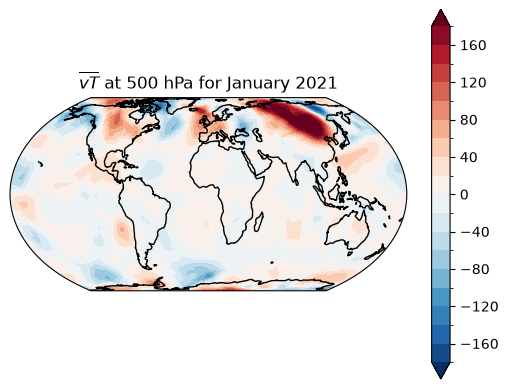

In [17]:
vTbar = (v500 * (T500 - T500_global)).mean(dim='valid_time')
levs = np.linspace(-180,180, 19)
make_map(vTbar, levels=levs, title=r'$\overline{vT}$ at 500 hPa for January 2021')

How much of the full field is captured by the time mean advection of the time mean temperature?

(Note, the time means here include any eddies that are stationary on our averaging timescale, which is seasonal here)

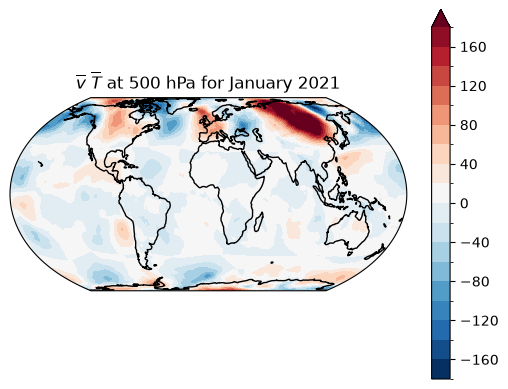

In [18]:
vbar = v500.mean(dim='valid_time').compute()
Tbar = T500.mean(dim='valid_time') - T500_global

make_map(vbar * Tbar, levels=levs, title=r'$\overline{v}~\overline{T}$ at 500 hPa for January 2021')

And now let's look at the transient eddy contribution

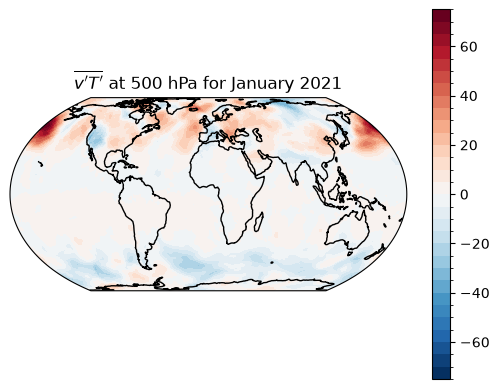

In [19]:
vprime = v500 - vbar
Tprime = (T500 - T500_global) - Tbar
vprime_Tprime_bar = (vprime*Tprime).mean(dim='valid_time')
make_map(vprime_Tprime_bar, title=r'$\overline{v^\prime T^\prime}$ at 500 hPa for January 2021')

### Now look at contributions to the zonal average

Consider the decomposition

$$ [\overline{vT}] = [\overline{v}][\overline{T}] + [\overline{v}^* \overline{T}^*] + [\overline{v^\prime T^\prime}] $$

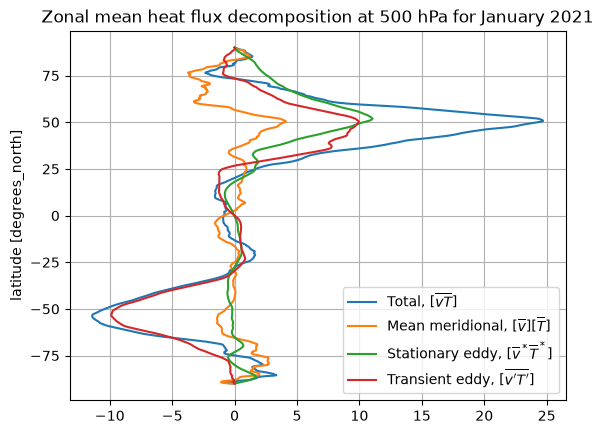

In [20]:
vTbar_zon = vTbar.mean(dim='longitude')
vbar_zon = vbar.mean(dim='longitude')
Tbar_zon = Tbar.mean(dim='longitude')
vbarzon_Tbarzon = vbar_zon * Tbar_zon
vbar_star = vbar - vbar_zon
Tbar_star = Tbar - Tbar_zon
vbarstar_Tbarstar_zon = (vbar_star * Tbar_star).mean(dim='longitude')
vprime_Tprime_bar_zon = vprime_Tprime_bar.mean(dim='longitude')

vTbar_zon.plot(y='latitude', label=r'Total, $[\overline{vT}]$')
vbarzon_Tbarzon.plot(y='latitude', label=r'Mean meridional, $[\overline{v}][\overline{T}]$')
vbarstar_Tbarstar_zon.plot(y='latitude', label=r'Stationary eddy, $[\overline{v}^* \overline{T}^*]$')
vprime_Tprime_bar_zon.plot(y='latitude', label=r'Transient eddy, $[\overline{v^\prime T^\prime}]$')
plt.legend()
plt.grid()
plt.title('Zonal mean heat flux decomposition at 500 hPa for January 2021');

### What does it mean to have a positive "stationary eddy" component?

The plot above shows that there are maximum in poleward heat flux near 50º latitude in both hemispheres. While the *transient eddy* term $[\overline{v^\prime T^\prime}]$ (red) is large in both hemispheres, there is a substantial positive (northward) *stationary eddy* $[\overline{v}^* \overline{T}^*]$ contribution in the Northern Hemisphere.

What is this, and what does it mean?

#### Map of zonal temperature anomalies $\overline{T}^*$

Let's take a quick look at the map of $\overline{T}^*$ to get a sense of its contribution to $[\overline{v}^* \overline{T}^*]$

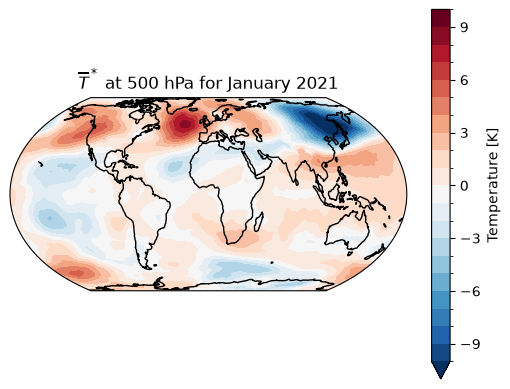

In [21]:
make_map(Tbar_star, levels=np.linspace(-10,10,21), title=r'$\overline{T}^*$ at 500 hPa for January 2021');

Focussing on the Northern mid-latitudes, there is a prominent wavenumber-2 pattern with alternating warm and cold anomalies. The warm anomalies are centered over the eastern parts of the ocean basins, while the cold anomalies are centered over the eastern continents.

This looks like a "smoothed out" version of the zonal temperature anomalies at 1000 hPa that we've already seen.

#### Map of zonal wind anomalies $\overline{v}^*$

Similarly we can plot $\overline{v}^*$ and look for spatial covariance between the anomalous meridional flow and the anomalous temperature fields:

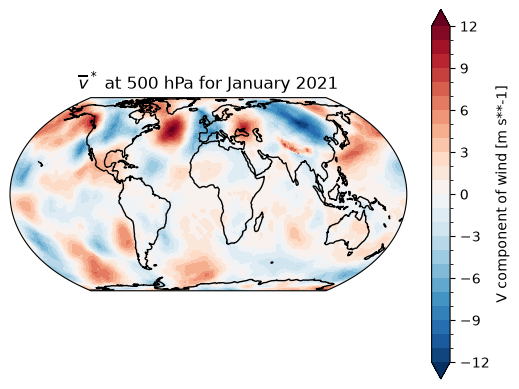

In [22]:
make_map(vbar_star, levels=np.linspace(-12,12,25), title=r'$\overline{v}^*$ at 500 hPa for January 2021');

Here, focussing again on the Northern mid-latitudes, we can see that there are regions where the seasonally-averaged meridional flow is anomalously *northward* (red) and *southward* (blue).

The key point is that there is *covariance* between these two fields: the regions of *northward* flow (over the ocean basins) tend to also be regions of anomalously *warm* temperatures, while the regions of *southward* flow (over the continents) tend to also be regions of anomalously *cold* temperatures.

Thus the product $[\overline{v}^* \overline{T}^*]$ is positive in the zonal average, even though the individual zonal averages $[\overline{v}^*]$, $[\overline{T}^*]$ are both zero by definition!

### Zonal mean heat fluxes in the opposite season

Let's just repeat the whole calculation for June through August 2021.

First though, we'll wrap our calculation and plotting code in functions for easier repetition with different time periods.

In [23]:
def calc_zonal_heat_flux(dateslice, lev=500):
    v500 = pressure_spatial.v.sel(pressure_level = 500., valid_time=dateslice)
    T500 = pressure_spatial.t.sel(pressure_level = 500., valid_time=dateslice)

    T500_global = T500.mean(dim='valid_time').weighted(np.cos(np.deg2rad(T500.latitude))).mean(dim=('latitude','longitude')).compute()

    vTbar = (v500 * (T500 - T500_global)).mean(dim='valid_time')
    vbar = v500.mean(dim='valid_time')
    Tbar = T500.mean(dim='valid_time') - T500_global

    vTbar_zon = vTbar.mean(dim='longitude')
    vbar_zon = vbar.mean(dim='longitude')
    Tbar_zon = Tbar.mean(dim='longitude')
    vprime = v500 - vbar
    Tprime = (T500 - T500_global) - Tbar
    vprime_Tprime_bar = (vprime*Tprime).mean(dim='valid_time')

    vbarzon_Tbarzon = vbar_zon * Tbar_zon
    vbar_star = vbar - vbar_zon
    Tbar_star = Tbar - Tbar_zon
    vbarstar_Tbarstar_zon = (vbar_star * Tbar_star).mean(dim='longitude')
    vprime_Tprime_bar_zon = vprime_Tprime_bar.mean(dim='longitude')
    
    decomp = {'vTbar': vTbar_zon,
              'vbar_Tbar': vbarzon_Tbarzon,
              'vbarstar_Tbarstar': vbarstar_Tbarstar_zon,
              'vprime_Tprime_bar': vprime_Tprime_bar_zon}
    return decomp

def plot_zonal_heat_flux(decomp):
    decomp['vTbar'].plot(y='latitude', label=r'Total, $[\overline{vT}]$')
    decomp['vbar_Tbar'].plot(y='latitude', label=r'Mean meridional, $[\overline{v}][\overline{T}]$')
    decomp['vbarstar_Tbarstar'].plot(y='latitude', label=r'Stationary eddy, $[\overline{v}^* \overline{T}^*]$')
    decomp['vprime_Tprime_bar'].plot(y='latitude', label=r'Transient eddy, $[\overline{v^\prime T^\prime}]$')
    plt.legend()
    plt.grid()
    return 

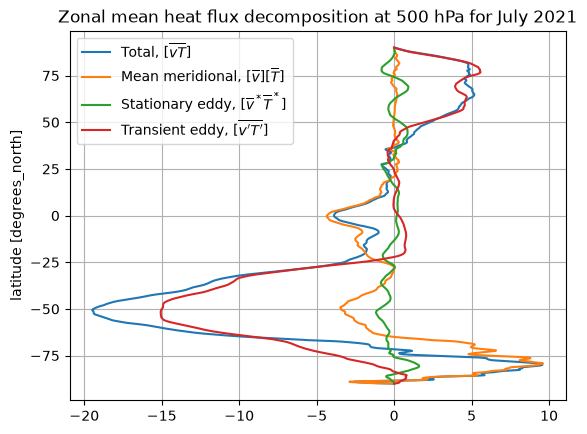

In [24]:
plot_zonal_heat_flux(calc_zonal_heat_flux(dateslice=slice('2021-07-01','2021-07-31')))
plt.title('Zonal mean heat flux decomposition at 500 hPa for July 2021');

Here we can see a few differences:
- The NH peak is much smaller in summer than winter (by a factor of ~4)
- The SH peak is stronger in its summer, but the winter-summer contrast in the SH is smaller than in the NH
- Unlike in NH winter, there is very little stationary eddy contribution in the SH winter

## Dependence on averaging period

The decomposition between transient and stationary fluxes depend on the chosen averaging period.

For very short time periods, $\left[\overline{A^\prime B^\prime}\right] \rightarrow 0$. The transient eddies disappear and all fluctuations appear as stationary eddies.

For timescales of ~3 months, the stationary eddies are seasonal features such as the Aleutian Low, and transient eddies are anything with residence times < 3 months (e.g. traveling synoptic systems)

At 12 month timescale, we have mostly transient eddies but still some stationary features due to orographic forcing.

### Zonal mean flux over 1 week

Let's repeat a calculation but change the averaging period from 1 months down to 1 week:

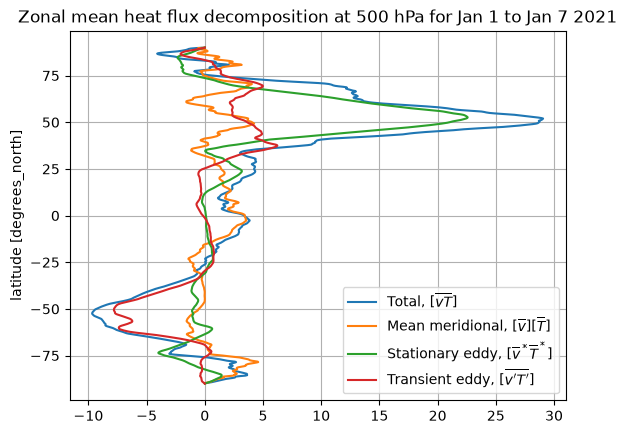

In [25]:
plot_zonal_heat_flux(calc_zonal_heat_flux(dateslice=slice('2021-01-01','2021-01-07')))
plt.title('Zonal mean heat flux decomposition at 500 hPa for Jan 1 to Jan 7 2021');

### Zonal mean heat flux over 1 year

And do the whole year:

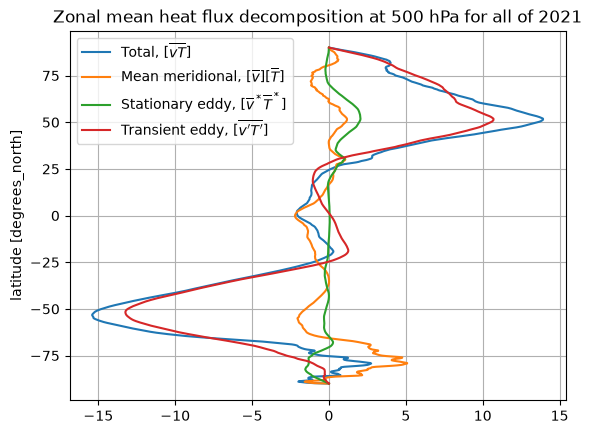

In [26]:
plot_zonal_heat_flux(calc_zonal_heat_flux(dateslice=slice('2021-01-01','2021-12-31')))
plt.title('Zonal mean heat flux decomposition at 500 hPa for all of 2021');

We can see that the partition between *stationary eddy* and *transient eddy* is particularly sensitive to our choice of averaging interval.